In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Пути
BASE = os.path.join("..", "models")
model = joblib.load(os.path.join(BASE, "model.pkl"))
scaler = joblib.load(os.path.join(BASE, "scaler.pkl"))
columns = joblib.load(os.path.join(BASE, "columns.pkl"))

print("Модель:", type(model).__name__)
print("Признаков:", len(columns))

Модель: GradientBoostingClassifier
Признаков: 23


In [2]:
from sklearn.model_selection import train_test_split

DATA_PATH = os.path.join("..", "data", "credit_data.xls")
df = pd.read_excel(DATA_PATH, header=1)
df = df.rename(columns={"default payment next month": "target"})
df = df.drop(columns=["ID"])

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_test_scaled = scaler.transform(X_test)
print("Тестовая выборка:", X_test_scaled.shape)

Тестовая выборка: (9000, 23)


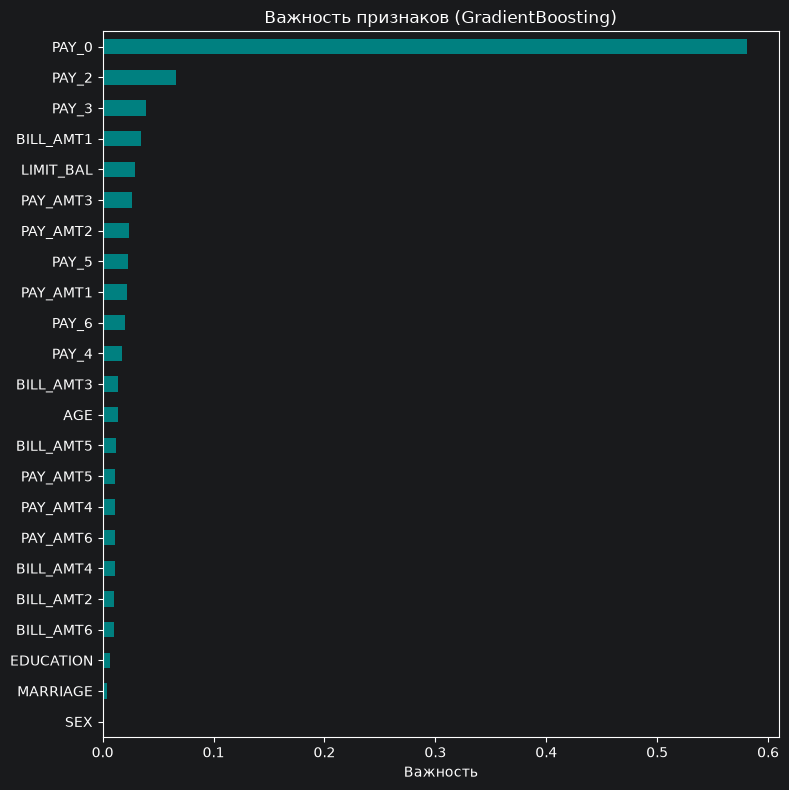

Топ-5 признаков:
LIMIT_BAL    0.0290
BILL_AMT1    0.0344
PAY_3        0.0395
PAY_2        0.0663
PAY_0        0.5808
dtype: float64


In [3]:
if hasattr(model, "feature_importances_"):
    imp = pd.Series(model.feature_importances_, index=columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 8))
    imp.plot(kind="barh", color="teal", ax=ax)
    ax.set_title("Важность признаков (GradientBoosting)")
    ax.set_xlabel("Важность")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=100)
    plt.show()

    print("Топ-5 признаков:")
    print(imp.tail(5).round(4))
else:
    print("Модель не поддерживает feature_importances_ (например, LogReg)")

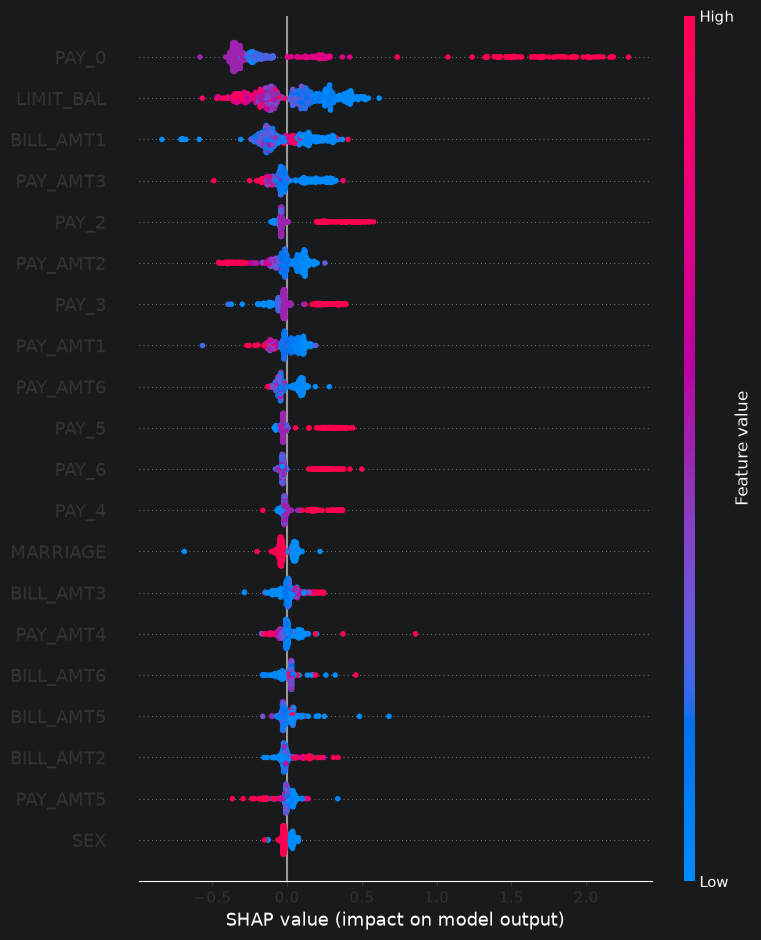

In [4]:
# Для скорости берём 500 примеров
X_sample = X_test_scaled[:500]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample, feature_names=columns, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=100)
plt.show()

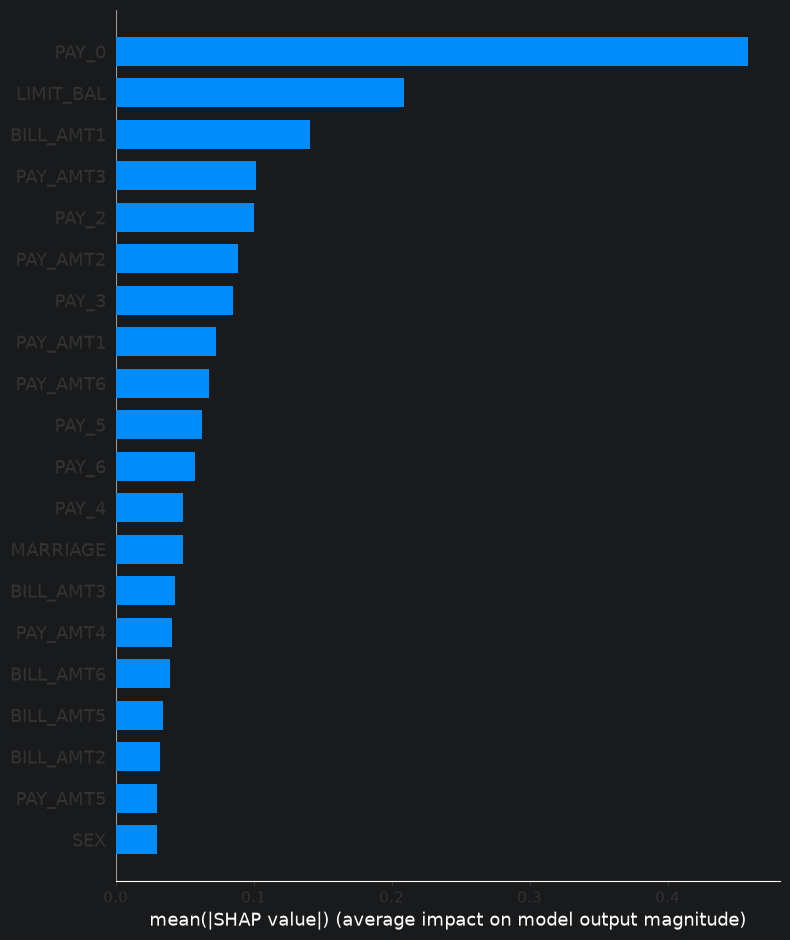

In [5]:
shap.summary_plot(shap_values, X_sample, feature_names=columns,
                  plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=100)
plt.show()

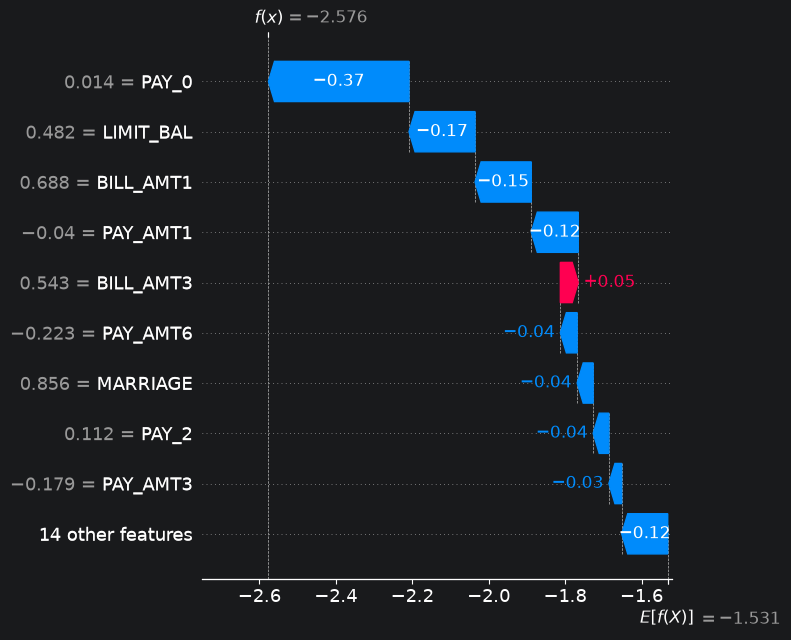

In [6]:
import numpy as np

idx = 0

# Приводим expected_value к скаляру (устойчиво к разным версиям SHAP)
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(np.array(base_value).ravel()[-1])
else:
    base_value = float(base_value)

# SHAP-значения тоже могут быть списком или массивом
sv = shap_values
if isinstance(sv, list):
    sv = sv[-1]   # берём вклады в класс "дефолт"

shap.waterfall_plot(
    shap.Explanation(
        values=sv[idx],
        base_values=base_value,
        data=X_sample[idx],
        feature_names=columns
    ),
    show=False
)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=100)
plt.show()

Надёжный клиент — вероятность дефолта: 7.07%
Рискованный клиент — вероятность дефолта: 44.36%


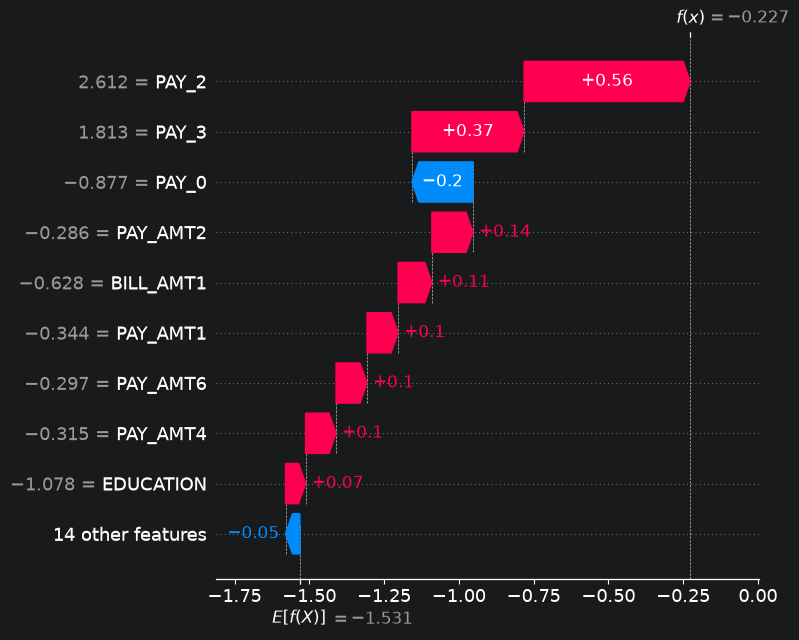

In [7]:
import numpy as np

def get_base_value(explainer):
    bv = explainer.expected_value
    if isinstance(bv, (list, np.ndarray)):
        return float(np.array(bv).ravel()[-1])
    return float(bv)

def get_shap_for_default(shap_vals):
    if isinstance(shap_vals, list):
        return shap_vals[-1]
    return shap_vals

base_value = get_base_value(explainer)

# Надёжный клиент
safe = X_test[y_test == 0].iloc[0:1]
safe_scaled = scaler.transform(safe)
proba_safe = model.predict_proba(safe_scaled)[0, 1]
print(f"Надёжный клиент — вероятность дефолта: {proba_safe:.2%}")

# Рискованный клиент
risky = X_test[y_test == 1].iloc[0:1]
risky_scaled = scaler.transform(risky)
proba_risky = model.predict_proba(risky_scaled)[0, 1]
print(f"Рискованный клиент — вероятность дефолта: {proba_risky:.2%}")

# SHAP для рискованного
shap_risky = explainer.shap_values(risky_scaled)
sv_risky = get_shap_for_default(shap_risky)

shap.waterfall_plot(
    shap.Explanation(
        values=sv_risky[0],
        base_values=base_value,
        data=risky_scaled[0],
        feature_names=columns
    ),
    show=False
)
plt.tight_layout()
plt.savefig("shap_waterfall_risky.png", dpi=100)
plt.show()

In [8]:
print("""
=== ВЫВОДЫ ИНТЕРПРЕТАЦИИ ===

1. Топ-признаки по важности: PAY_0, PAY_2, PAY_3, LIMIT_BAL, PAY_AMT1.
   Это согласуется с EDA: история просрочек определяет дефолт.

2. SHAP summary показывает:
   - Высокий PAY_0 (просрочка) → ↑ вероятность дефолта.
   - Высокий LIMIT_BAL (большой лимит) → ↓ вероятность дефолта.
   - Демографические признаки (SEX, EDUCATION, MARRIAGE)
     почти не влияют на предсказание.

3. Waterfall plot объясняет одно конкретное предсказание:
   видно, какие признаки сдвинули вероятность вверх, а какие — вниз.

4. Практический вывод: модель можно упростить, исключив
   SEX, MARRIAGE, EDUCATION — это снизит риск дискриминации
   и не ухудшит качество.
""")


=== ВЫВОДЫ ИНТЕРПРЕТАЦИИ ===

1. Топ-признаки по важности: PAY_0, PAY_2, PAY_3, LIMIT_BAL, PAY_AMT1.
   Это согласуется с EDA: история просрочек определяет дефолт.

2. SHAP summary показывает:
   - Высокий PAY_0 (просрочка) → ↑ вероятность дефолта.
   - Высокий LIMIT_BAL (большой лимит) → ↓ вероятность дефолта.
   - Демографические признаки (SEX, EDUCATION, MARRIAGE)
     почти не влияют на предсказание.

3. Waterfall plot объясняет одно конкретное предсказание:
   видно, какие признаки сдвинули вероятность вверх, а какие — вниз.

4. Практический вывод: модель можно упростить, исключив
   SEX, MARRIAGE, EDUCATION — это снизит риск дискриминации
   и не ухудшит качество.

